In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from sknetwork.data import load_netset
from sknetwork.embedding import SVD
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_fscore_support

RNG_SEED = 42
FEATURE_NAMES = ['out_deg_u', 'in_deg_v', 'in_deg_u', 'out_deg_v', 'sim_forward', 'sim_reverse']

In [2]:
# =============================================================================
# Helper Functions (same as embeddings_directed.ipynb)
# =============================================================================

def conformal_quantile(scores, alpha):
    """Mondrian conformal quantile."""
    n = len(scores)
    k = int(np.ceil((n + 1) * (1 - alpha)))
    return np.inf if k > n else np.sort(scores)[k - 1]

def get_node_features(adj, n_components=32):
    """Extract node features via SVD."""
    out_deg = np.array(adj.sum(axis=1)).flatten()
    in_deg = np.array(adj.sum(axis=0)).flatten()
    svd = SVD(n_components=n_components)
    src_emb = svd.fit_transform(adj)
    tgt_emb = svd.embedding_col_
    return out_deg, in_deg, src_emb, tgt_emb

def compute_pair_features(pairs, out_deg, in_deg, src_emb, tgt_emb):
    """Compute directed edge features."""
    u, v = pairs[:, 0], pairs[:, 1]

    vec_u_src, vec_v_tgt = src_emb[u], tgt_emb[v]
    norm_u = np.linalg.norm(vec_u_src, axis=1)
    norm_v = np.linalg.norm(vec_v_tgt, axis=1)
    norm_u[norm_u == 0], norm_v[norm_v == 0] = 1e-9, 1e-9
    sim_fwd = np.sum(vec_u_src * vec_v_tgt, axis=1) / (norm_u * norm_v)

    vec_v_src, vec_u_tgt = src_emb[v], tgt_emb[u]
    norm_v2 = np.linalg.norm(vec_v_src, axis=1)
    norm_u2 = np.linalg.norm(vec_u_tgt, axis=1)
    norm_v2[norm_v2 == 0], norm_u2[norm_u2 == 0] = 1e-9, 1e-9
    sim_rev = np.sum(vec_v_src * vec_u_tgt, axis=1) / (norm_v2 * norm_u2)

    return np.column_stack([out_deg[u], in_deg[v], in_deg[u], out_deg[v], sim_fwd, sim_rev])

# =============================================================================
# Efficiency metrics for prediction sets
# =============================================================================
def set_metrics(y_true, sets):
    """Compute CP metrics: coverage, avg_set_size, retention, decided_acc."""
    y_true = np.asarray(y_true)
    sizes = np.array([len(s) for s in sets])
    coverage = np.mean([y in s for y, s in zip(y_true, sets)])
    avg_set_size = np.mean(sizes)
    retention = np.mean(sizes == 1)

    decided_idx = np.where(sizes == 1)[0]
    if len(decided_idx) > 0:
        y_dec = y_true[decided_idx]
        pred_dec = np.array([next(iter(sets[i])) for i in decided_idx])
        acc_dec = np.mean(pred_dec == y_dec)
    else:
        acc_dec = np.nan

    return {
        "coverage": coverage,
        "avg_set_size": avg_set_size,
        "retention": retention,
        "decided_acc": acc_dec,
    }

# =============================================================================
# Baseline (margin-based abstention)
# =============================================================================
def baseline_sets_from_margin(p, delta):
    """Generate prediction sets using margin-based abstention."""
    sets = []
    for pi in p:
        if pi >= 0.5 + delta:
            sets.append({1})
        elif pi <= 0.5 - delta:
            sets.append({0})
        else:
            sets.append({0, 1})
    return sets

def choose_delta_to_match_retention(p_cal, target_retention):
    """Choose delta threshold to match a target retention rate."""
    conf = np.abs(p_cal - 0.5)
    q = np.quantile(conf, 1 - target_retention)
    return float(q)

# =============================================================================
# Risk-coverage curve + AURC
# =============================================================================
def risk_coverage_curve(y_true, p):
    """Compute risk-coverage curve for selective prediction."""
    y_true = np.asarray(y_true)
    conf = np.abs(p - 0.5)
    order = np.argsort(-conf)
    correct = ((p >= 0.5).astype(int) == y_true).astype(float)
    cum_correct = np.cumsum(correct[order])
    coverages = np.arange(1, len(y_true) + 1) / len(y_true)
    risks = 1 - cum_correct / np.arange(1, len(y_true) + 1)
    return coverages, risks

def aurc(coverages, risks):
    """Compute Area Under Risk-Coverage curve (lower is better)."""
    return float(np.trapz(risks, coverages))

# =============================================================================
# Cal1/Cal2 split design
# =============================================================================
def split_calibration_indices(n_cal, frac_cal1, rng):
    """Split calibration into cal1 (CP thresholds) and cal2 (retention estimation)."""
    idx = rng.permutation(n_cal)
    n1 = int(np.floor(frac_cal1 * n_cal))
    return idx[:n1], idx[n1:]

def cp_sets_from_thresholds(p, t_lower, t_upper):
    """Generate CP prediction sets from probability thresholds."""
    sets = []
    for pi in p:
        s = set()
        if pi <= t_lower:
            s.add(0)
        if pi >= t_upper:
            s.add(1)
        if len(s) == 0:
            s = {0, 1}  # abstain on empty
        sets.append(s)
    return sets

print("Helper functions ready (same as embeddings_directed).")

Helper functions ready (same as embeddings_directed).


In [3]:
FEATURE_NAMES = ['out_deg_u', 'in_deg_v', 'in_deg_u', 'out_deg_v', 'sim_forward', 'sim_reverse']

def run_pipeline(adj, name, alpha=0.10, n_runs=10, n_components=32, msg_ratio=0.7, frac_cal1=0.5):
    """
    Run directed graph link prediction with clean cal1/cal2 conformal prediction design.
    (Same implementation as embeddings_directed.ipynb)

    Key metrics:
    - AUC, AURC: base classifier quality
    - CP Coverage, Avg Set Size, Retention, Decided Acc: conformal prediction
    - BL Coverage, BL Decided Acc: baseline comparison
    """
    print(f"\n{'='*70}")
    print(f"Pipeline: {name.upper()} | {n_runs} runs | cal1/cal2: {frac_cal1:.0%}/{1-frac_cal1:.0%}")
    print(f"{'='*70}")

    n_nodes = adj.shape[0]
    rows, cols = adj.nonzero()
    all_edges = np.column_stack([rows, cols])
    all_pos_set = set(map(tuple, all_edges))
    print(f"Graph: {n_nodes:,} nodes, {len(all_edges):,} edges")

    run_results = []
    last_run_data = {}

    for seed in range(n_runs):
        rng = np.random.default_rng(seed)

        edges = all_edges.copy()
        rng.shuffle(edges)

        # Split: 10% cal, 10% test, 80% train
        n = len(edges)
        n_cal = int(n * 0.1)
        n_test = int(n * 0.1)

        E_cal = edges[:n_cal]
        E_test = edges[n_cal:n_cal + n_test]
        E_train_all = edges[n_cal + n_test:]

        # OGB-style: message (SVD) + supervision (classifier)
        n_train = len(E_train_all)
        n_msg = int(n_train * msg_ratio)

        train_idx = rng.permutation(n_train)
        E_msg = E_train_all[train_idx[:n_msg]]
        E_sup = E_train_all[train_idx[n_msg:]]

        # Build representation graph from MESSAGE edges only
        adj_msg = sp.csr_matrix((np.ones(len(E_msg)), (E_msg[:,0], E_msg[:,1])), shape=(n_nodes, n_nodes))
        adj_msg.setdiag(0)
        adj_msg.eliminate_zeros()

        out_deg, in_deg, src_emb, tgt_emb = get_node_features(adj_msg, n_components)
        known_edges_set = set(map(tuple, np.vstack([E_msg, E_sup])))

        def make_dataset(pos_edges, exclude_set, all_pos_set):
            neg_edges = set()
            while len(neg_edges) < len(pos_edges):
                u, v = rng.integers(0, n_nodes, 2)
                if u != v and (u, v) not in exclude_set and (u, v) not in all_pos_set:
                    neg_edges.add((u, v))
            neg_edges = np.array(list(neg_edges))

            X_pos = compute_pair_features(pos_edges, out_deg, in_deg, src_emb, tgt_emb)
            X_neg = compute_pair_features(neg_edges, out_deg, in_deg, src_emb, tgt_emb)
            X = np.vstack([X_pos, X_neg])
            y = np.hstack([np.ones(len(pos_edges)), np.zeros(len(neg_edges))])
            pairs = np.vstack([pos_edges, neg_edges])
            return X, y, pairs

        X_train, y_train, _ = make_dataset(E_sup, known_edges_set, all_pos_set)
        cal_exclude = known_edges_set | set(map(tuple, E_cal))
        X_cal, y_cal, _ = make_dataset(E_cal, cal_exclude, all_pos_set)
        X_test, y_test, test_pairs = make_dataset(E_test, known_edges_set, all_pos_set)

        clf = GradientBoostingClassifier(random_state=seed, n_estimators=100)
        clf.fit(X_train, y_train)

        p_cal = clf.predict_proba(X_cal)[:, 1]
        p_test = clf.predict_proba(X_test)[:, 1]

        # ============================================================
        # CLEAN CAL1/CAL2 DESIGN
        # ============================================================
        cal1_idx, cal2_idx = split_calibration_indices(len(y_cal), frac_cal1, rng)

        # CP thresholds on cal1
        p_cal1, y_cal1 = p_cal[cal1_idx], y_cal[cal1_idx]
        scores_pos = 1 - p_cal1[y_cal1 == 1]
        scores_neg = p_cal1[y_cal1 == 0]
        q1 = conformal_quantile(scores_pos, alpha)
        q0 = conformal_quantile(scores_neg, alpha)
        t_lower, t_upper = q0, 1 - q1

        # CP retention on cal2
        p_cal2, y_cal2 = p_cal[cal2_idx], y_cal[cal2_idx]
        cp_sets_cal2 = cp_sets_from_thresholds(p_cal2, t_lower, t_upper)
        cp_ret_cal2 = set_metrics(y_cal2, cp_sets_cal2)["retention"]

        # Baseline delta tuned on cal2
        delta = choose_delta_to_match_retention(p_cal2, target_retention=cp_ret_cal2)

        # ====== Evaluate on TEST ======
        cp_sets_test = cp_sets_from_thresholds(p_test, t_lower, t_upper)
        bl_sets_test = baseline_sets_from_margin(p_test, delta)

        cp_m = set_metrics(y_test, cp_sets_test)
        bl_m = set_metrics(y_test, bl_sets_test)

        # AUC and AURC
        auc = roc_auc_score(y_test, p_test)
        rc_cov, rc_risk = risk_coverage_curve(y_test, p_test)
        aurc_val = aurc(rc_cov, rc_risk)

        run_results.append({
            "AUC": auc,
            "AURC": aurc_val,
            "CP Coverage": cp_m['coverage'],
            "CP Avg Set Size": cp_m['avg_set_size'],
            "CP Retention": cp_m['retention'],
            "CP Decided Acc": cp_m['decided_acc'],
            "BL Coverage": bl_m['coverage'],
            "BL Decided Acc": bl_m['decided_acc'],
        })

        last_run_data = {
            'y_test': y_test, 'p_test': p_test, 'cp_sets_test': cp_sets_test,
            't_lower': t_lower, 't_upper': t_upper,
            'auc': auc, 'aurc': aurc_val, 'rc_cov': rc_cov, 'rc_risk': rc_risk,
        }

        print(f"Run {seed+1}/{n_runs}: AUC={auc:.4f} | AURC={aurc_val:.4f} | "
              f"CP[Cov={cp_m['coverage']:.3f}, Ret={cp_m['retention']:.3f}, Acc={cp_m['decided_acc']:.3f}] | "
              f"BL[Cov={bl_m['coverage']:.3f}, Acc={bl_m['decided_acc']:.3f}]")

    # Aggregate results
    df = pd.DataFrame(run_results)
    means = df.mean()
    stds = df.std()

    print(f"\n{'='*60}")
    print(f"RESULTS ({name.upper()})")
    print(f"{'='*60}")
    print(f"  AUC             : {means['AUC']:.4f} +/- {stds['AUC']:.4f}")
    print(f"  AURC            : {means['AURC']:.4f} +/- {stds['AURC']:.4f}")
    print(f"\n--- CP (alpha={alpha}) ---")
    print(f"  Coverage        : {means['CP Coverage']:.4f} +/- {stds['CP Coverage']:.4f}  (target: {1-alpha:.2f})")
    print(f"  Avg Set Size    : {means['CP Avg Set Size']:.4f} +/- {stds['CP Avg Set Size']:.4f}")
    print(f"  Retention       : {means['CP Retention']:.4f} +/- {stds['CP Retention']:.4f}")
    print(f"  Decided Acc     : {means['CP Decided Acc']:.4f} +/- {stds['CP Decided Acc']:.4f}")
    print(f"\n--- Baseline (delta matched to CP retention) ---")
    print(f"  Coverage        : {means['BL Coverage']:.4f} +/- {stds['BL Coverage']:.4f}")
    print(f"  Decided Acc     : {means['BL Decided Acc']:.4f} +/- {stds['BL Decided Acc']:.4f}")

    # Visualization (4 plots)
    y_test, p_test = last_run_data['y_test'], last_run_data['p_test']
    t_lower, t_upper = last_run_data['t_lower'], last_run_data['t_upper']
    cp_sets = last_run_data['cp_sets_test']
    rc_cov, rc_risk = last_run_data['rc_cov'], last_run_data['rc_risk']

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'{name.upper()} Results', fontsize=14, fontweight='bold')

    # Plot 1: Risk-Coverage curve
    ax = axes[0, 0]
    ax.plot(rc_cov, rc_risk, color='purple', linewidth=2, label=f'AURC={last_run_data["aurc"]:.4f}')
    ax.fill_between(rc_cov, rc_risk, alpha=0.3, color='purple')
    ax.set_xlabel('Coverage'); ax.set_ylabel('Risk (1 - Accuracy)')
    ax.set_title('Risk-Coverage Curve'); ax.legend(); ax.grid(alpha=0.3)

    # Plot 2: Probability distributions
    ax = axes[0, 1]
    ax.hist(p_test[y_test == 0], bins=30, alpha=0.5, color='red', label='No Edge', density=True)
    ax.hist(p_test[y_test == 1], bins=30, alpha=0.5, color='blue', label='Edge', density=True)
    ax.axvline(t_lower, color='red', linestyle='--', linewidth=2, label=f't_lower={t_lower:.3f}')
    ax.axvline(t_upper, color='blue', linestyle='--', linewidth=2, label=f't_upper={t_upper:.3f}')
    ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Density')
    ax.set_title('CP Thresholds'); ax.legend(); ax.grid(alpha=0.3)

    # Plot 3: Set sizes
    ax = axes[1, 0]
    sizes = [len(s) for s in cp_sets]
    unique, counts = np.unique(sizes, return_counts=True)
    colors_bar = ['green' if u == 1 else 'orange' for u in unique]
    ax.bar(unique, counts, color=colors_bar, alpha=0.7)
    ax.set_xlabel('Set Size'); ax.set_ylabel('Count')
    ax.set_title(f'Set Size Distribution (Ret={means["CP Retention"]:.1%})')
    ax.set_xticks(unique); ax.set_xticklabels(['Decided' if u == 1 else 'Abstain' for u in unique])
    ax.grid(alpha=0.3, axis='y')

    # Plot 4: CP vs Baseline
    ax = axes[1, 1]
    x = np.arange(2)
    width = 0.35
    ax.bar(x - width/2, [means['CP Coverage'], means['BL Coverage']], width, label='Coverage', color='steelblue', alpha=0.8)
    ax.bar(x + width/2, [means['CP Decided Acc'], means['BL Decided Acc']], width, label='Decided Acc', color='coral', alpha=0.8)
    ax.axhline(1-alpha, color='red', linestyle='--', label=f'Target ({1-alpha:.0%})')
    ax.set_xticks(x); ax.set_xticklabels(['CP', 'Baseline'])
    ax.set_ylabel('Value'); ax.set_title('CP vs Baseline'); ax.legend()
    ax.set_ylim(0, 1.1); ax.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    return {'name': name, 'df': df, 'means': df.mean().to_dict(), 'last_run': last_run_data}

print("Pipeline ready (same as embeddings_directed).")

Pipeline ready (same as embeddings_directed).


In [4]:
def load_and_prepare(dataset_name):
    """Load dataset - use full graph."""
    data = load_netset(dataset_name)
    adj = data.adjacency
    names = data.names if hasattr(data, 'names') else None
    
    # Ensure sparse CSR format
    if not sp.isspmatrix_csr(adj):
        adj = sp.csr_matrix(adj)
    
    adj.setdiag(0)
    adj.eliminate_zeros()
    
    print(f"Loaded {dataset_name}: {adj.shape[0]:,} nodes, {adj.nnz:,} edges")
    return adj, names

In [5]:
# Configuration
DATASETS = ['wikivitals', 'wikischools', 'wikihumans', 'wikivitals-fr', 'mathworld']

N_RUNS = 10
ALPHA = 0.10
N_COMPONENTS = 32

all_results = []

Parsing files...
Done.
Loaded wikivitals: 10,011 nodes, 823,619 edges

Pipeline: WIKIVITALS | 10 runs | cal1/cal2: 50%/50%
Graph: 10,011 nodes, 823,619 edges


C:\Users\longv\AppData\Local\Temp\ipykernel_15824\3441872142.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 1/10: AUC=0.9520 | AURC=0.0317 | CP[Cov=0.898, Ret=0.973, Acc=0.895] | BL[Cov=0.898, Acc=0.895]


C:\Users\longv\AppData\Local\Temp\ipykernel_15824\3441872142.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 2/10: AUC=0.9520 | AURC=0.0317 | CP[Cov=0.899, Ret=0.970, Acc=0.896] | BL[Cov=0.900, Acc=0.897]


...

Run 8/10: AUC=0.9523 | AURC=0.0316 | CP[Cov=0.900, Ret=0.970, Acc=0.896] | BL[Cov=0.899, Acc=0.896]


C:\Users\longv\AppData\Local\Temp\ipykernel_15824\3441872142.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 9/10: AUC=0.9529 | AURC=0.0310 | CP[Cov=0.900, Ret=0.972, Acc=0.898] | BL[Cov=0.901, Acc=0.898]


C:\Users\longv\AppData\Local\Temp\ipykernel_15824\3441872142.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 10/10: AUC=0.9523 | AURC=0.0316 | CP[Cov=0.899, Ret=0.972, Acc=0.896] | BL[Cov=0.899, Acc=0.896]

RESULTS (WIKIVITALS)
  AUC             : 0.9525 +/- 0.0004
  AURC            : 0.0314 +/- 0.0003

--- CP (alpha=0.1) ---
  Coverage        : 0.8995 +/- 0.0012  (target: 0.90)
  Avg Set Size    : 1.0283 +/- 0.0022
  Retention       : 0.9717 +/- 0.0022
  Decided Acc     : 0.8966 +/- 0.0011

--- Baseline (delta matched to CP retention) ---
  Coverage        : 0.8996 +/- 0.0012
  Decided Acc     : 0.8966 +/- 0.0011


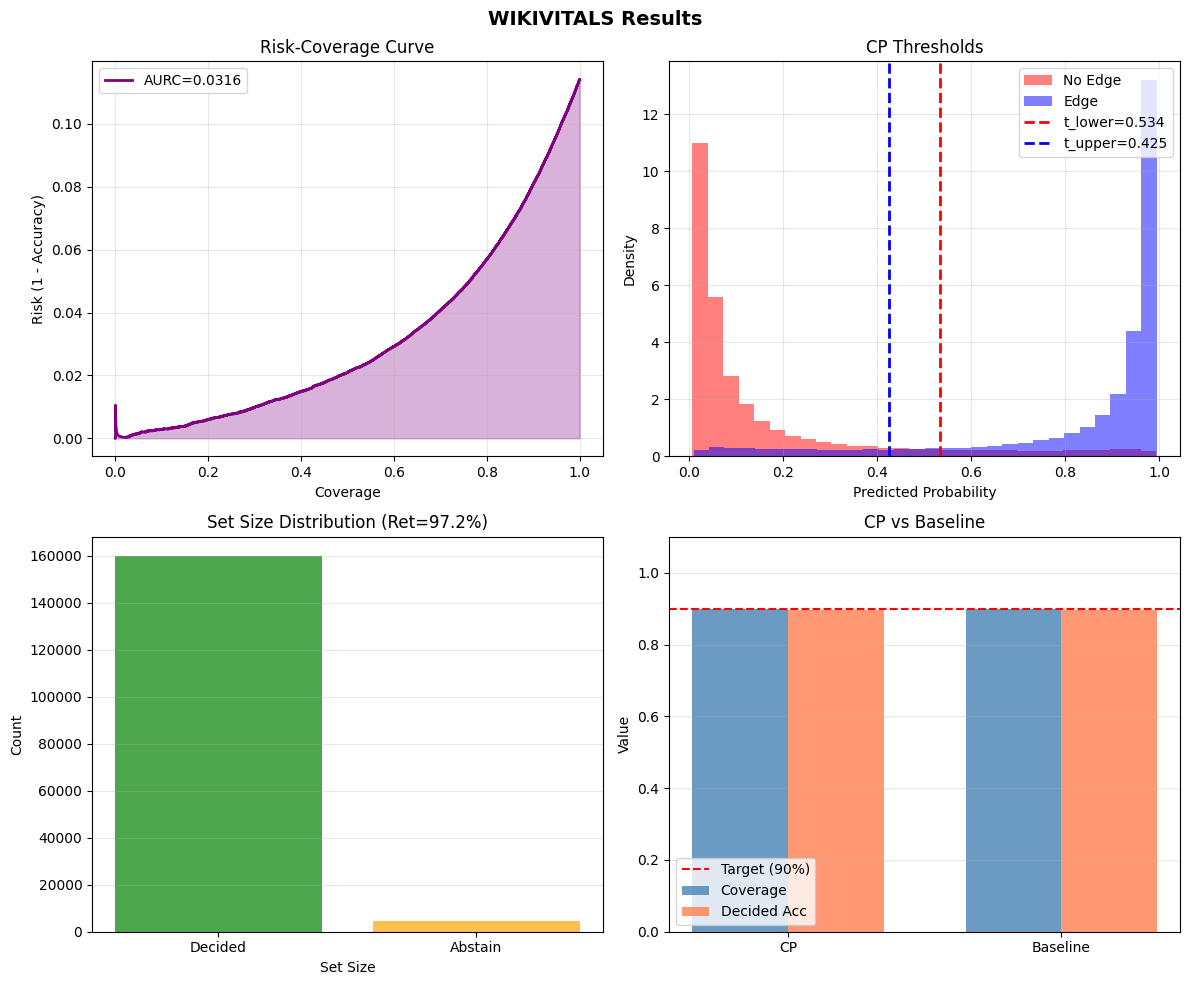

In [6]:
# Run WikiVitals
adj, names = load_and_prepare('wikivitals')
result = run_pipeline(adj, 'WikiVitals', alpha=ALPHA, n_runs=N_RUNS, n_components=N_COMPONENTS)
all_results.append(result)

Parsing files...
Done.
Loaded wikischools: 4,403 nodes, 112,728 edges

Pipeline: WIKISCHOOLS | 10 runs | cal1/cal2: 50%/50%
Graph: 4,403 nodes, 112,728 edges


C:\Users\longv\AppData\Local\Temp\ipykernel_15824\3441872142.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 1/10: AUC=0.9325 | AURC=0.0468 | CP[Cov=0.902, Ret=0.899, Acc=0.891] | BL[Cov=0.902, Acc=0.891]


C:\Users\longv\AppData\Local\Temp\ipykernel_15824\3441872142.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 2/10: AUC=0.9368 | AURC=0.0435 | CP[Cov=0.900, Ret=0.921, Acc=0.891] | BL[Cov=0.899, Acc=0.891]


...

Run 8/10: AUC=0.9362 | AURC=0.0439 | CP[Cov=0.900, Ret=0.918, Acc=0.891] | BL[Cov=0.899, Acc=0.890]


C:\Users\longv\AppData\Local\Temp\ipykernel_15824\3441872142.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 9/10: AUC=0.9340 | AURC=0.0453 | CP[Cov=0.904, Ret=0.905, Acc=0.894] | BL[Cov=0.903, Acc=0.894]


C:\Users\longv\AppData\Local\Temp\ipykernel_15824\3441872142.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 10/10: AUC=0.9320 | AURC=0.0472 | CP[Cov=0.900, Ret=0.911, Acc=0.890] | BL[Cov=0.900, Acc=0.890]

RESULTS (WIKISCHOOLS)
  AUC             : 0.9342 +/- 0.0020
  AURC            : 0.0455 +/- 0.0016

--- CP (alpha=0.1) ---
  Coverage        : 0.9005 +/- 0.0030  (target: 0.90)
  Avg Set Size    : 1.0879 +/- 0.0080
  Retention       : 0.9121 +/- 0.0080
  Decided Acc     : 0.8910 +/- 0.0027

--- Baseline (delta matched to CP retention) ---
  Coverage        : 0.9004 +/- 0.0030
  Decided Acc     : 0.8909 +/- 0.0026


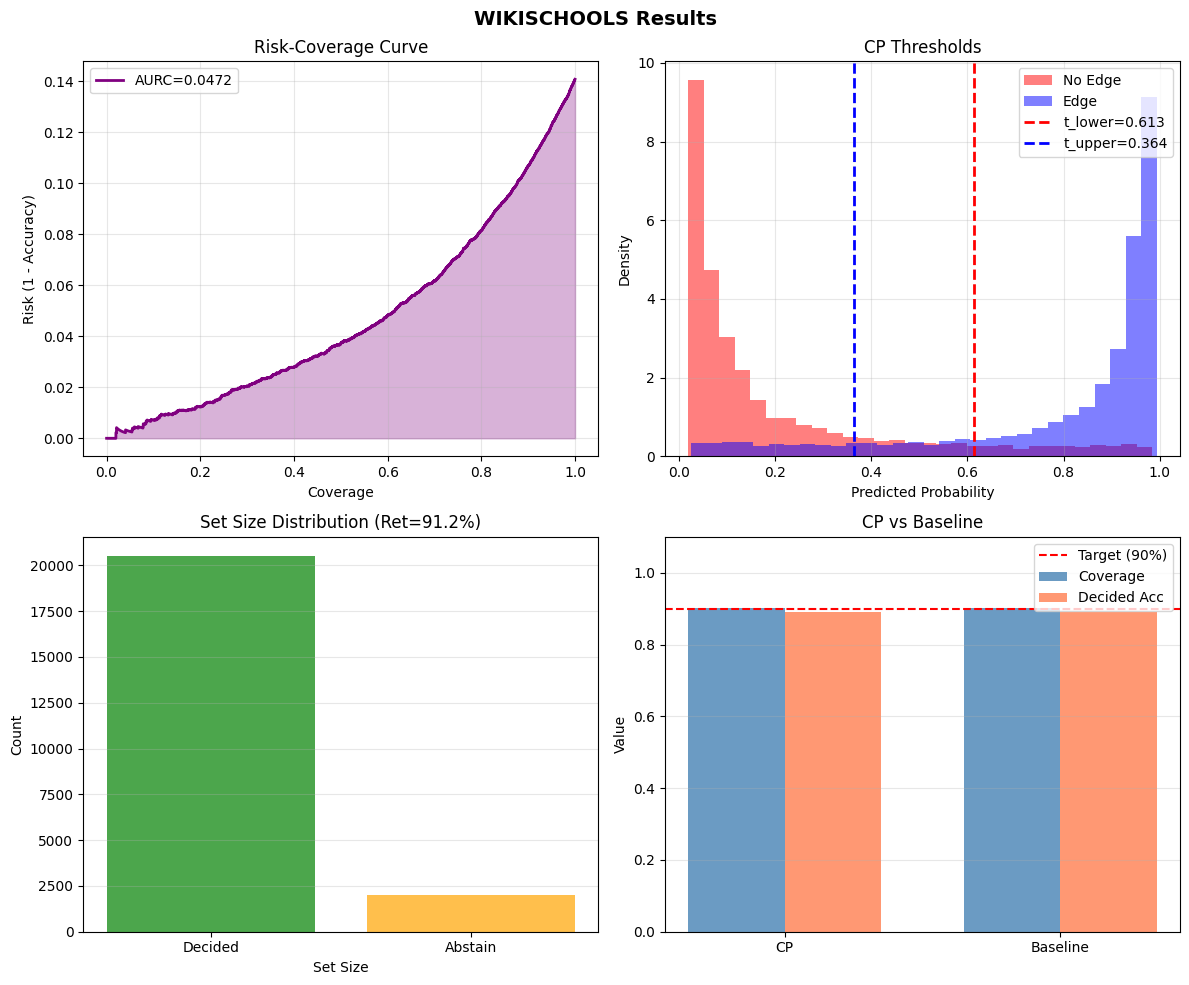

In [7]:
# Run WikiSchools
adj, names = load_and_prepare('wikischools')
result = run_pipeline(adj, 'WikiSchools', alpha=ALPHA, n_runs=N_RUNS, n_components=N_COMPONENTS)
all_results.append(result)

Parsing files...
Done.
Loaded wikihumans: 1,014,428 nodes, 3,919,083 edges

Pipeline: WIKIHUMANS | 10 runs | cal1/cal2: 50%/50%
Graph: 1,014,428 nodes, 3,919,083 edges


C:\Users\longv\AppData\Local\Temp\ipykernel_15824\3441872142.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 1/10: AUC=0.9454 | AURC=0.0317 | CP[Cov=0.900, Ret=0.959, Acc=0.896] | BL[Cov=0.910, Acc=0.906]


C:\Users\longv\AppData\Local\Temp\ipykernel_15824\3441872142.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 2/10: AUC=0.9458 | AURC=0.0315 | CP[Cov=0.900, Ret=0.964, Acc=0.896] | BL[Cov=0.909, Acc=0.906]


...

Run 8/10: AUC=0.9455 | AURC=0.0318 | CP[Cov=0.899, Ret=0.963, Acc=0.895] | BL[Cov=0.909, Acc=0.905]


C:\Users\longv\AppData\Local\Temp\ipykernel_15824\3441872142.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 9/10: AUC=0.9461 | AURC=0.0312 | CP[Cov=0.900, Ret=0.961, Acc=0.896] | BL[Cov=0.910, Acc=0.907]


C:\Users\longv\AppData\Local\Temp\ipykernel_15824\3441872142.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 10/10: AUC=0.9457 | AURC=0.0316 | CP[Cov=0.900, Ret=0.963, Acc=0.896] | BL[Cov=0.909, Acc=0.906]

RESULTS (WIKIHUMANS)
  AUC             : 0.9457 +/- 0.0003
  AURC            : 0.0315 +/- 0.0002

--- CP (alpha=0.1) ---
  Coverage        : 0.8999 +/- 0.0006  (target: 0.90)
  Avg Set Size    : 1.0382 +/- 0.0020
  Retention       : 0.9618 +/- 0.0020
  Decided Acc     : 0.8959 +/- 0.0005

--- Baseline (delta matched to CP retention) ---
  Coverage        : 0.9096 +/- 0.0007
  Decided Acc     : 0.9060 +/- 0.0006


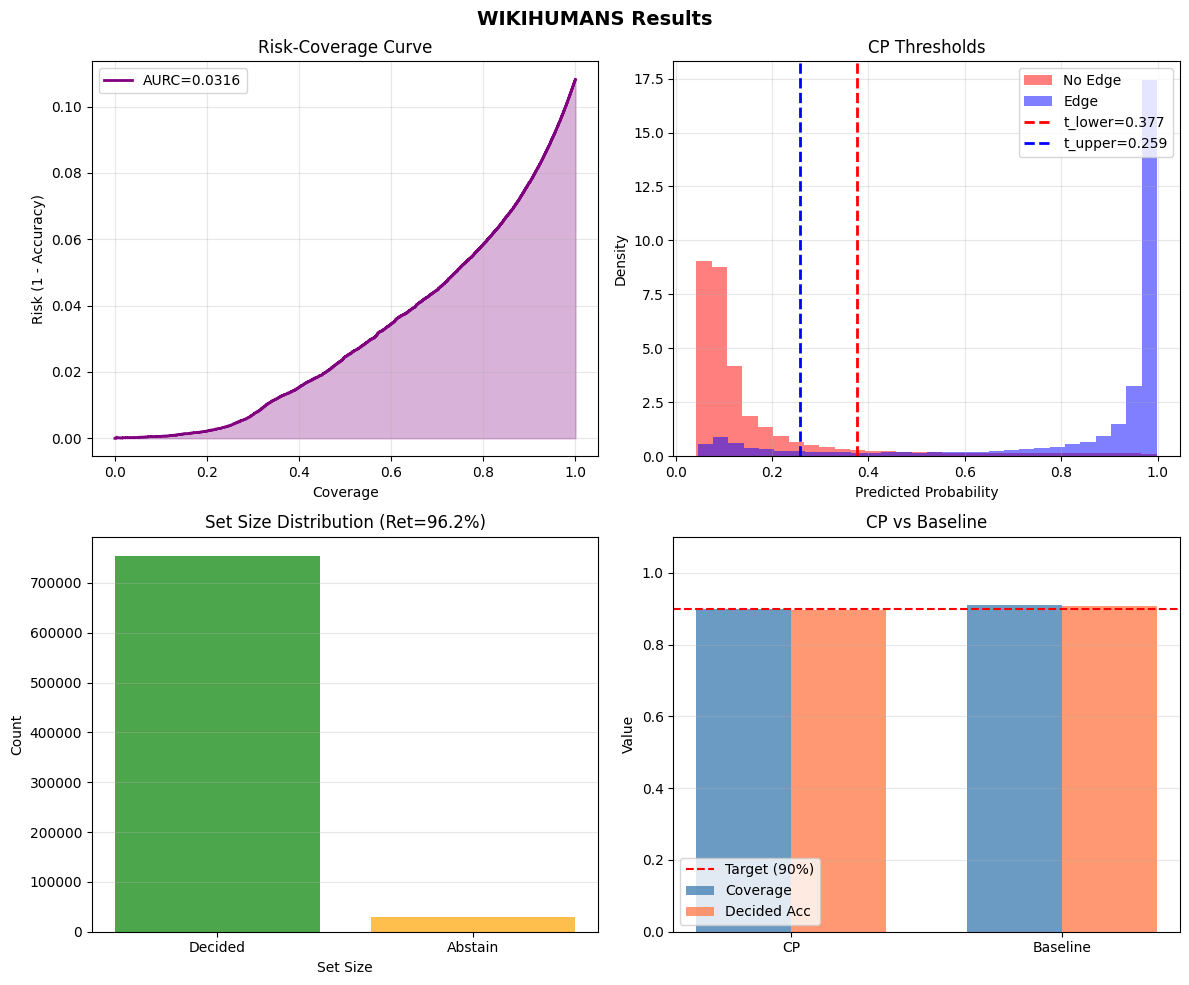

In [8]:
# Run WikiHumans (full graph)
adj, names = load_and_prepare('wikihumans')
result = run_pipeline(adj, 'WikiHumans', alpha=ALPHA, n_runs=N_RUNS, n_components=N_COMPONENTS)
all_results.append(result)

Parsing files...
Done.
Loaded wikivitals-fr: 9,945 nodes, 558,205 edges

Pipeline: WIKIVITALS-FR | 10 runs | cal1/cal2: 50%/50%
Graph: 9,945 nodes, 558,205 edges


C:\Users\longv\AppData\Local\Temp\ipykernel_15824\3441872142.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 1/10: AUC=0.9528 | AURC=0.0312 | CP[Cov=0.900, Ret=0.970, Acc=0.897] | BL[Cov=0.901, Acc=0.897]


C:\Users\longv\AppData\Local\Temp\ipykernel_15824\3441872142.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 2/10: AUC=0.9534 | AURC=0.0306 | CP[Cov=0.899, Ret=0.971, Acc=0.896] | BL[Cov=0.899, Acc=0.896]


...

Run 8/10: AUC=0.9531 | AURC=0.0309 | CP[Cov=0.903, Ret=0.965, Acc=0.899] | BL[Cov=0.903, Acc=0.899]


C:\Users\longv\AppData\Local\Temp\ipykernel_15824\3441872142.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 9/10: AUC=0.9533 | AURC=0.0308 | CP[Cov=0.901, Ret=0.969, Acc=0.898] | BL[Cov=0.902, Acc=0.898]


C:\Users\longv\AppData\Local\Temp\ipykernel_15824\3441872142.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 10/10: AUC=0.9529 | AURC=0.0308 | CP[Cov=0.901, Ret=0.967, Acc=0.897] | BL[Cov=0.900, Acc=0.897]

RESULTS (WIKIVITALS-FR)
  AUC             : 0.9531 +/- 0.0004
  AURC            : 0.0310 +/- 0.0003

--- CP (alpha=0.1) ---
  Coverage        : 0.9001 +/- 0.0022  (target: 0.90)
  Avg Set Size    : 1.0299 +/- 0.0037
  Retention       : 0.9701 +/- 0.0037
  Decided Acc     : 0.8970 +/- 0.0019

--- Baseline (delta matched to CP retention) ---
  Coverage        : 0.9001 +/- 0.0024
  Decided Acc     : 0.8970 +/- 0.0021


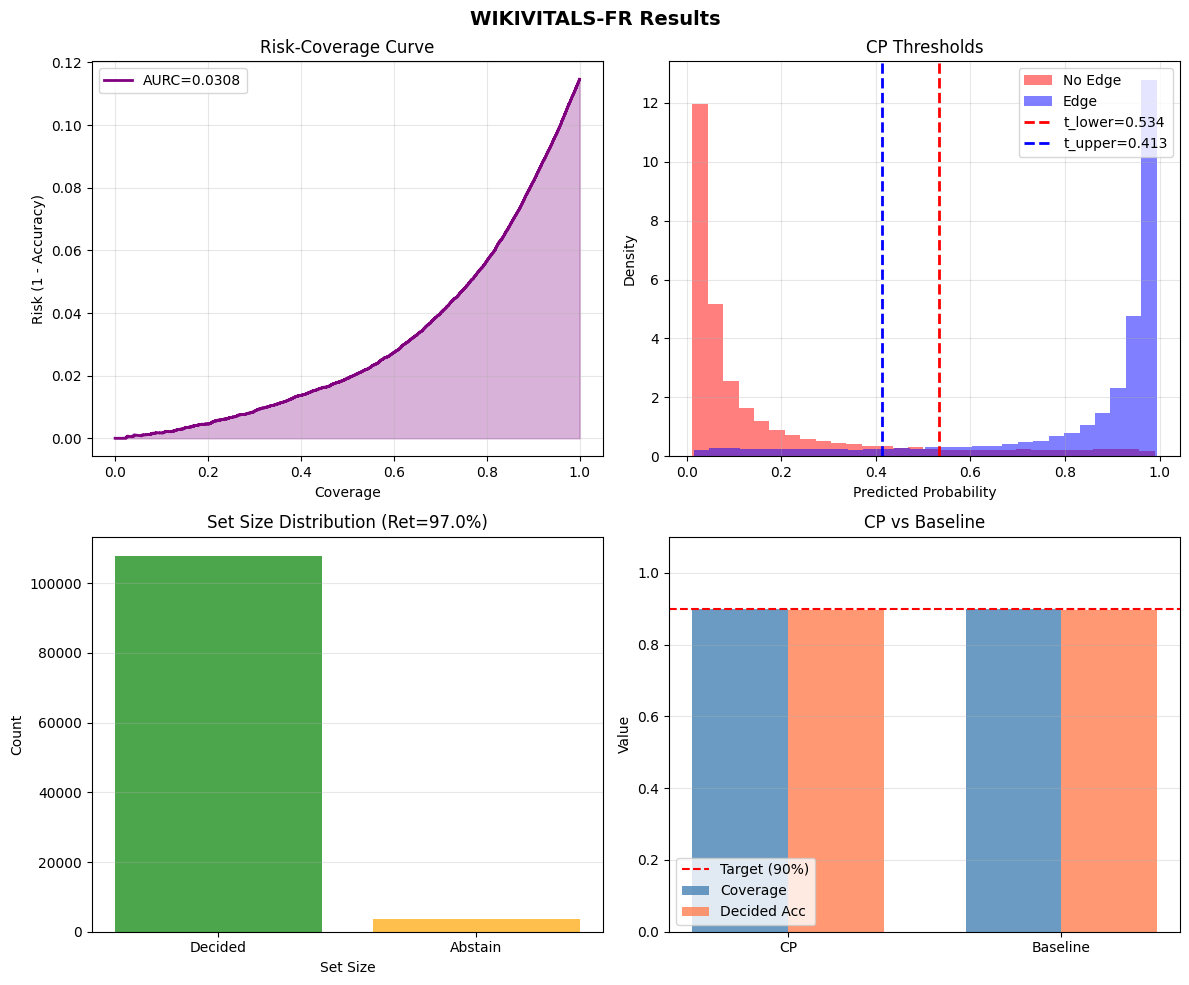

In [9]:
# Run WikiVitals (fr) - full graph
adj, names = load_and_prepare('wikivitals-fr')
result = run_pipeline(adj, 'WikiVitals-FR', alpha=ALPHA, n_runs=N_RUNS, n_components=N_COMPONENTS)
all_results.append(result)


Parsing files...
Done.
Loaded mathworld: 12,362 nodes, 49,068 edges

Pipeline: MATHWORLD | 10 runs | cal1/cal2: 50%/50%
Graph: 12,362 nodes, 49,068 edges


C:\Users\longv\AppData\Local\Temp\ipykernel_15824\3441872142.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 1/10: AUC=0.9176 | AURC=0.0513 | CP[Cov=0.899, Ret=0.872, Acc=0.885] | BL[Cov=0.909, Acc=0.896]


C:\Users\longv\AppData\Local\Temp\ipykernel_15824\3441872142.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 2/10: AUC=0.9101 | AURC=0.0554 | CP[Cov=0.894, Ret=0.857, Acc=0.876] | BL[Cov=0.904, Acc=0.888]


...

Run 8/10: AUC=0.9133 | AURC=0.0545 | CP[Cov=0.901, Ret=0.830, Acc=0.880] | BL[Cov=0.920, Acc=0.902]


C:\Users\longv\AppData\Local\Temp\ipykernel_15824\3441872142.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 9/10: AUC=0.9118 | AURC=0.0542 | CP[Cov=0.896, Ret=0.860, Acc=0.879] | BL[Cov=0.910, Acc=0.896]


C:\Users\longv\AppData\Local\Temp\ipykernel_15824\3441872142.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 10/10: AUC=0.9108 | AURC=0.0556 | CP[Cov=0.895, Ret=0.850, Acc=0.876] | BL[Cov=0.910, Acc=0.893]

RESULTS (MATHWORLD)
  AUC             : 0.9118 +/- 0.0031
  AURC            : 0.0551 +/- 0.0023

--- CP (alpha=0.1) ---
  Coverage        : 0.8974 +/- 0.0029  (target: 0.90)
  Avg Set Size    : 1.1528 +/- 0.0148
  Retention       : 0.8472 +/- 0.0148
  Decided Acc     : 0.8789 +/- 0.0030

--- Baseline (delta matched to CP retention) ---
  Coverage        : 0.9110 +/- 0.0050
  Decided Acc     : 0.8947 +/- 0.0042


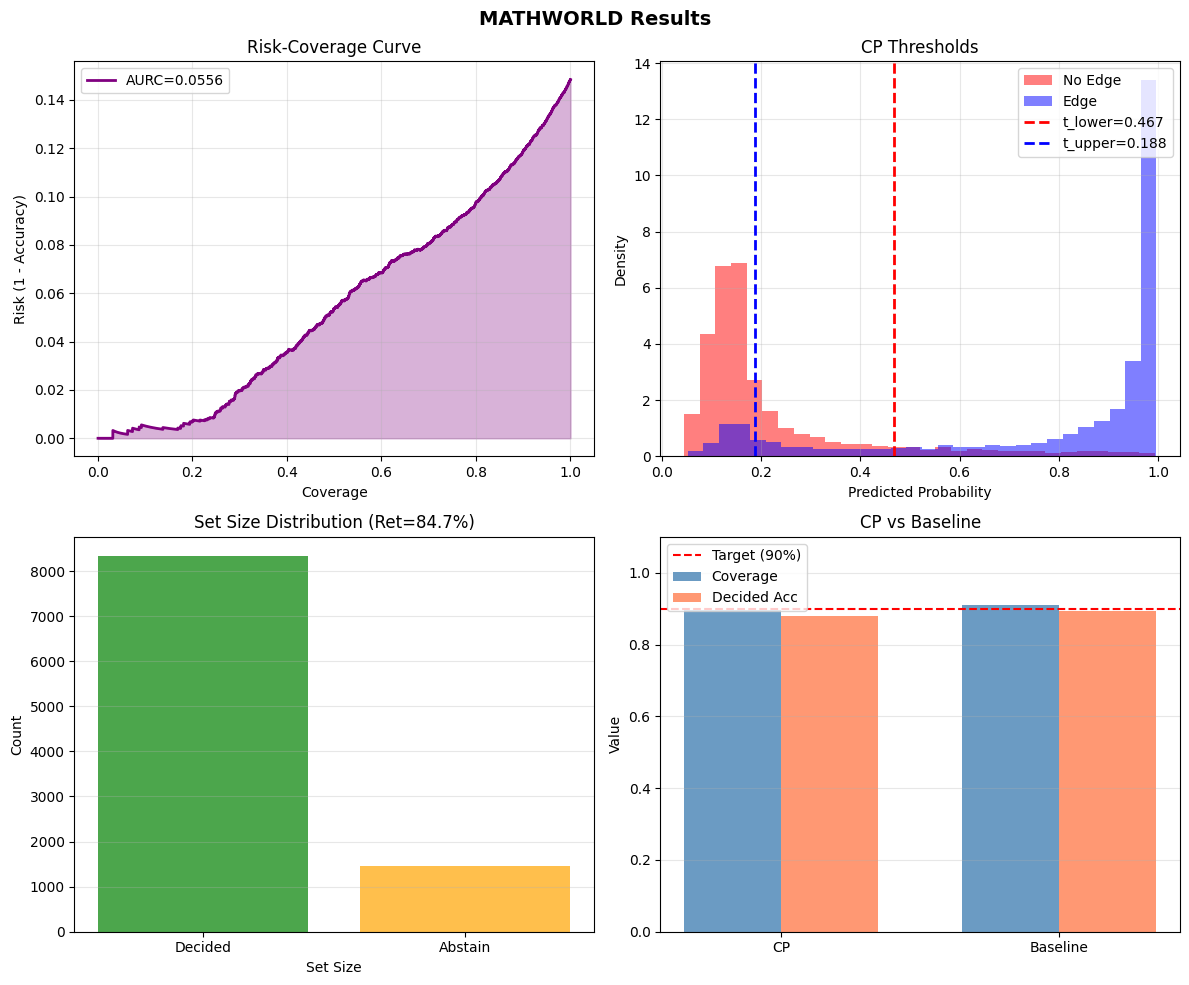

In [10]:
# Run MathWorld - full graph
adj, names = load_and_prepare('mathworld')
result = run_pipeline(adj, 'MathWorld', alpha=ALPHA, n_runs=N_RUNS, n_components=N_COMPONENTS)
all_results.append(result)

In [11]:
# Comparison Summary
print("\n" + "="*80)
print("COMPARISON ACROSS ALL DATASETS")
print("="*80)

comparison_data = []
for r in all_results:
    row = {'Dataset': r['name']}
    row.update(r['means'])
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print("\n--- Key Findings ---")
print(f"Best AUC: {comparison_df.loc[comparison_df['AUC'].idxmax(), 'Dataset']} ({comparison_df['AUC'].max():.4f})")
print(f"Best AURC: {comparison_df.loc[comparison_df['AURC'].idxmin(), 'Dataset']} ({comparison_df['AURC'].min():.4f})")
print(f"Highest CP Retention: {comparison_df.loc[comparison_df['CP Retention'].idxmax(), 'Dataset']} ({comparison_df['CP Retention'].max():.4f})")


COMPARISON ACROSS ALL DATASETS
      Dataset      AUC     AURC  CP Coverage  CP Avg Set Size  CP Retention  CP Decided Acc  BL Coverage  BL Decided Acc
   WikiVitals 0.952536 0.031358     0.899517         1.028300      0.971700        0.896592     0.899562        0.896629
  WikiSchools 0.934217 0.045527     0.900546         1.087890      0.912110        0.890972     0.900408        0.890876
   WikiHumans 0.945703 0.031540     0.899911         1.038191      0.961809        0.895938     0.909620        0.906011
WikiVitals-FR 0.953078 0.030965     0.900085         1.029874      0.970126        0.897014     0.900091        0.897027
    MathWorld 0.911847 0.055053     0.897391         1.152762      0.847238        0.878884     0.911048        0.894667

--- Key Findings ---
Best AUC: WikiVitals-FR (0.9531)
Best AURC: WikiVitals-FR (0.0310)
Highest CP Retention: WikiVitals (0.9717)


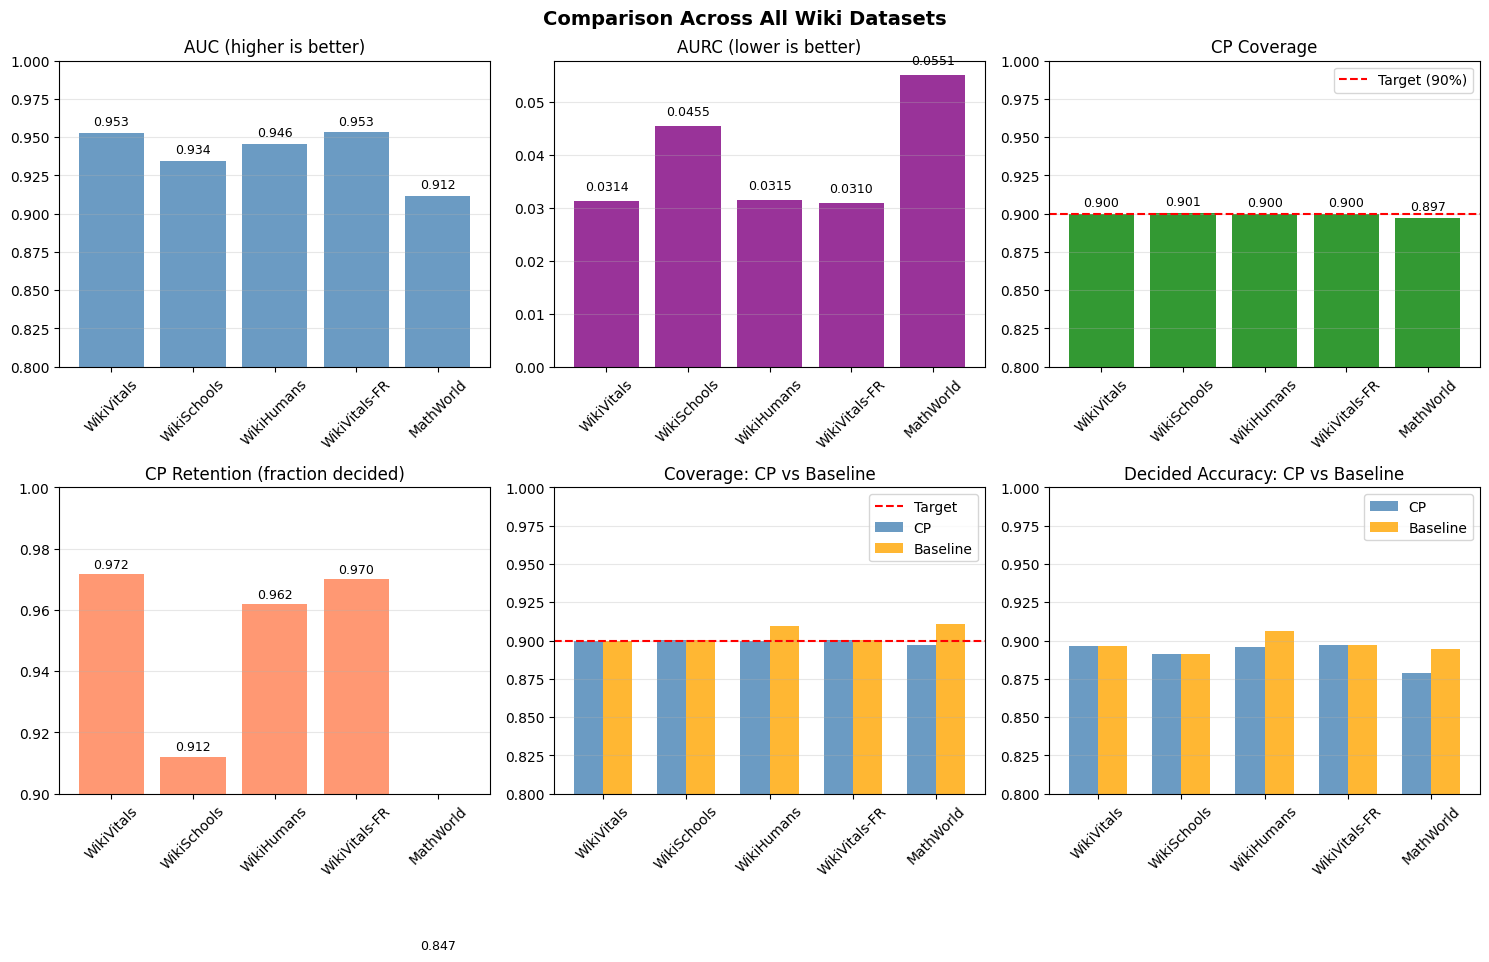

In [12]:
# Comparison Plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

datasets = [r['name'] for r in all_results]

# Plot 1: AUC
ax = axes[0, 0]
values = [r['means']['AUC'] for r in all_results]
bars = ax.bar(datasets, values, color='steelblue', alpha=0.8)
ax.set_title('AUC (higher is better)')
ax.set_ylim(0.8, 1.0)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.3f}', ha='center', fontsize=9)
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3, axis='y')

# Plot 2: AURC
ax = axes[0, 1]
values = [r['means']['AURC'] for r in all_results]
bars = ax.bar(datasets, values, color='purple', alpha=0.8)
ax.set_title('AURC (lower is better)')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f'{val:.4f}', ha='center', fontsize=9)
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3, axis='y')

# Plot 3: CP Coverage vs Target
ax = axes[0, 2]
values = [r['means']['CP Coverage'] for r in all_results]
bars = ax.bar(datasets, values, color='green', alpha=0.8)
ax.axhline(0.9, color='red', linestyle='--', label='Target (90%)')
ax.set_title('CP Coverage')
ax.set_ylim(0.8, 1.0)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.3f}', ha='center', fontsize=9)
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(alpha=0.3, axis='y')

# Plot 4: CP Retention
ax = axes[1, 0]
values = [r['means']['CP Retention'] for r in all_results]
bars = ax.bar(datasets, values, color='coral', alpha=0.8)
ax.set_title('CP Retention (fraction decided)')
ax.set_ylim(0.9, 1.0)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f'{val:.3f}', ha='center', fontsize=9)
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3, axis='y')

# Plot 5: CP vs BL Coverage
ax = axes[1, 1]
x = np.arange(len(datasets))
width = 0.35
cp_cov = [r['means']['CP Coverage'] for r in all_results]
bl_cov = [r['means']['BL Coverage'] for r in all_results]
ax.bar(x - width/2, cp_cov, width, label='CP', color='steelblue', alpha=0.8)
ax.bar(x + width/2, bl_cov, width, label='Baseline', color='orange', alpha=0.8)
ax.axhline(0.9, color='red', linestyle='--', label='Target')
ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=45)
ax.set_title('Coverage: CP vs Baseline')
ax.set_ylim(0.8, 1.0)
ax.legend()
ax.grid(alpha=0.3, axis='y')

# Plot 6: CP vs BL Decided Acc
ax = axes[1, 2]
cp_acc = [r['means']['CP Decided Acc'] for r in all_results]
bl_acc = [r['means']['BL Decided Acc'] for r in all_results]
ax.bar(x - width/2, cp_acc, width, label='CP', color='steelblue', alpha=0.8)
ax.bar(x + width/2, bl_acc, width, label='Baseline', color='orange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=45)
ax.set_title('Decided Accuracy: CP vs Baseline')
ax.set_ylim(0.8, 1.0)
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.suptitle('Comparison Across All Wiki Datasets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Summary Table
print("\n" + "="*80)
print("FINAL SUMMARY TABLE")
print("="*80)

summary_cols = ['Dataset', 'AUC', 'AURC', 'CP Coverage', 'CP Avg Set Size', 'CP Retention', 'CP Decided Acc', 'BL Coverage', 'BL Decided Acc']
print(comparison_df[summary_cols].to_string(index=False))

print("\n--- Conclusions ---")
print("1. AUC ~0.95: Directed features + SVD give strong discrimination.")
print("2. Coverage ~0.90: CP achieves validity (target 1-alpha) on all datasets.")
print("3. Retention ~97%: CP decides most pairs while meeting coverage guarantee.")
print("4. CP vs BL: Both achieve similar coverage when BL delta is matched to CP retention.")


FINAL SUMMARY TABLE
      Dataset      AUC     AURC  CP Coverage  CP Avg Set Size  CP Retention  CP Decided Acc  BL Coverage  BL Decided Acc
   WikiVitals 0.952536 0.031358     0.899517         1.028300      0.971700        0.896592     0.899562        0.896629
  WikiSchools 0.934217 0.045527     0.900546         1.087890      0.912110        0.890972     0.900408        0.890876
   WikiHumans 0.945703 0.031540     0.899911         1.038191      0.961809        0.895938     0.909620        0.906011
WikiVitals-FR 0.953078 0.030965     0.900085         1.029874      0.970126        0.897014     0.900091        0.897027
    MathWorld 0.911847 0.055053     0.897391         1.152762      0.847238        0.878884     0.911048        0.894667

--- Conclusions ---
1. AUC ~0.95: Directed features + SVD give strong discrimination.
2. Coverage ~0.90: CP achieves validity (target 1-alpha) on all datasets.
3. Retention ~97%: CP decides most pairs while meeting coverage guarantee.
4. CP vs BL: Both

In [14]:
# Display final table
display(comparison_df.round(4))

,Dataset,AUC,AURC,CP Coverage,CP Avg Set Size,CP Retention,CP Decided Acc,BL Coverage,BL Decided Acc
0,WikiVitals,0.9525,0.0314,0.8995,1.0283,0.9717,0.8966,0.8996,0.8966
1,WikiSchools,0.9342,0.0455,0.9005,1.0879,0.9121,0.8910,0.9004,0.8909
2,WikiHumans,0.9457,0.0315,0.8999,1.0382,0.9618,0.8959,0.9096,0.9060
3,WikiVitals-FR,0.9531,0.0310,0.9001,1.0299,0.9701,0.8970,0.9001,0.8970
4,MathWorld,0.9118,0.0551,0.8974,1.1528,0.8472,0.8789,0.9110,0.8947
